# Testing Outlier Removal
I will first break the data into a training and validation set. I will then scan the training set for points where the features with requested values deviate greatly from that value, and make a new training set with these points removed.

In [698]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from venus_ml import VenusDataset

## Dataset Initialization

In [699]:
r_state = 88
requested = {
    'k18_fw_mean': [1.4e3, 'Watts'],
    'g28_fw_mean': [4.3e3, 'Watts'],
    'inj_i_mean': [185, 'Amps'],
    'ext_i_mean': [137, 'Amps'],
    'mid_i_mean': [153, 'Amps'],
    'sext_i_mean': [430, 'Amps'],
    'extraction_v_mean': [20, 'kV'],
    'puller_v_mean': [2, 'kV'],
}

train_features = ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean", "inj_i_mean", "ext_i_mean", "mid_i_mean", "sext_i_mean", "x_ray_source_mean", "x_ray_exit_mean"]
run_selection = ['00', '01', '02', '03', '04', '05', '06','08a', '08b', '08c', '08d', '09', '10', '10b', '11', '11b', '12', '13', '14']
# run_selection = ['00', '01' ,'02', '03', '04', '05', '08a', '08b', '08c', '08d', '09', '11', '12', '13', '14']
# run_selection = ['00', '09']
full_features = train_features + list(requested.keys())
data_set_config = {
    "file_path": "../data/watch_data.parquet",
    "input_columns": full_features,
    "output_columns": ['fcv1_i_mean'],
    "run_selection": run_selection, 

}
dataset = VenusDataset(**data_set_config)
print(len(dataset))
# print(len(dataset), dataset.inputs.shape, dataset.outputs.shape, end='|')
# x = [print(feature) for feature in full_features]
print(list(requested.keys()))

26164
['k18_fw_mean', 'g28_fw_mean', 'inj_i_mean', 'ext_i_mean', 'mid_i_mean', 'sext_i_mean', 'extraction_v_mean', 'puller_v_mean']


## Helper Functions

In [700]:
import copy

def outlier_removal(dataset, feature, std_threshold=2):
    dataset_copy = copy.deepcopy(dataset)
    inputs, outputs = dataset_copy.inputs, dataset_copy.outputs
    
    mean = inputs[feature].mean()
    std = inputs[feature].std()
    lower_limit = mean - (std_threshold * std)
    upper_limit = mean + (std_threshold * std)
    
    mask = (inputs[feature] >= lower_limit) & (inputs[feature] <= upper_limit)
    
    dataset_copy.inputs = inputs[mask]
    dataset_copy.outputs = outputs[mask]
    return dataset_copy
    
def filter_training_set(dataset, features, std_threshold=2):
    for feature in features:
        dataset = outlier_removal(dataset, feature, std_threshold=std_threshold)
    return dataset

def set_training_features(dataset, features):
    dataset_copy = copy.deepcopy(dataset)
    dataset_copy.inputs = dataset.inputs[features].copy()
    return dataset_copy


## Dataset Setup


In [701]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list
feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

filtering_features = ['k18_fw_mean', 'g28_fw_mean', 'inj_i_mean', 'ext_i_mean', 'mid_i_mean', 'extraction_v_mean', 'puller_v_mean']
# filtering_features = ['k18_fw_mean', 'extraction_v_mean']

def get_splits(group, filtering_features,  std_threshold=2):
    train, validation = dataset.generate_splits(run_selection, validation_size=0.25, random_state=r_state)
    train_filtered = filter_training_set(train, filtering_features, std_threshold=std_threshold)
    train = set_training_features(train, get_features(feature_groups[group]))
    train_filtered = set_training_features(train_filtered, get_features(feature_groups[group]))
    validation = set_training_features(validation, get_features(feature_groups[group]))
    return train, train_filtered, validation

## Random Forest Comparison

In [702]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

rf_config = {
    'n_estimators': 200,
    'random_state': r_state,
    'n_jobs': -1,
}

def compare(train, train_filtered, validation, verbose=True):
    rf = RandomForestRegressor(**rf_config)
    rf_filtered = RandomForestRegressor(**rf_config)


    rf.fit(train.inputs, train.outputs.to_numpy().ravel())
    rf_filtered.fit(train_filtered.inputs, train_filtered.outputs.to_numpy().ravel())

    val_error = mean_squared_error(validation.outputs, rf.predict(validation.inputs))
    train_error = mean_squared_error(train.outputs, rf.predict(train.inputs))


    filtered_val_error = mean_squared_error(validation.outputs, rf_filtered.predict(validation.inputs))
    filtered_train_error = mean_squared_error(train_filtered.outputs, rf_filtered.predict(train_filtered.inputs))
    
    score = rf.score(validation.inputs, validation.outputs.to_numpy().ravel())
    filtered_score = rf_filtered.score(validation.inputs, validation.outputs.to_numpy().ravel())
    if verbose:
        print(f"Raw Dataset | Validation Error: {format(val_error, '1.3e')} | Train Error: {format(train_error, '1.3e')} | R^2: {format(score, '.4f')}")
        print(f"Filtered Dataset | Validation Error: {format(filtered_val_error, '1.3e')} | Train Error: {format(filtered_train_error, '1.3e')} | R^2: {format(filtered_score, '.4f')}\n")
    return val_error, train_error, filtered_val_error, filtered_train_error, rf, rf_filtered

___________________________
Group: S
Raw Dataset | Validation Error: 2.401e-09 | Train Error: 3.074e-10 | R^2: 0.9308
Filtered Dataset | Validation Error: 2.396e-09 | Train Error: 3.104e-10 | R^2: 0.9310

___________________________
Group: M
Raw Dataset | Validation Error: 1.116e-09 | Train Error: 1.492e-10 | R^2: 0.9679
Filtered Dataset | Validation Error: 1.115e-09 | Train Error: 1.506e-10 | R^2: 0.9679

___________________________
Group: L
Raw Dataset | Validation Error: 1.056e-09 | Train Error: 1.441e-10 | R^2: 0.9696
Filtered Dataset | Validation Error: 1.047e-09 | Train Error: 1.453e-10 | R^2: 0.9699



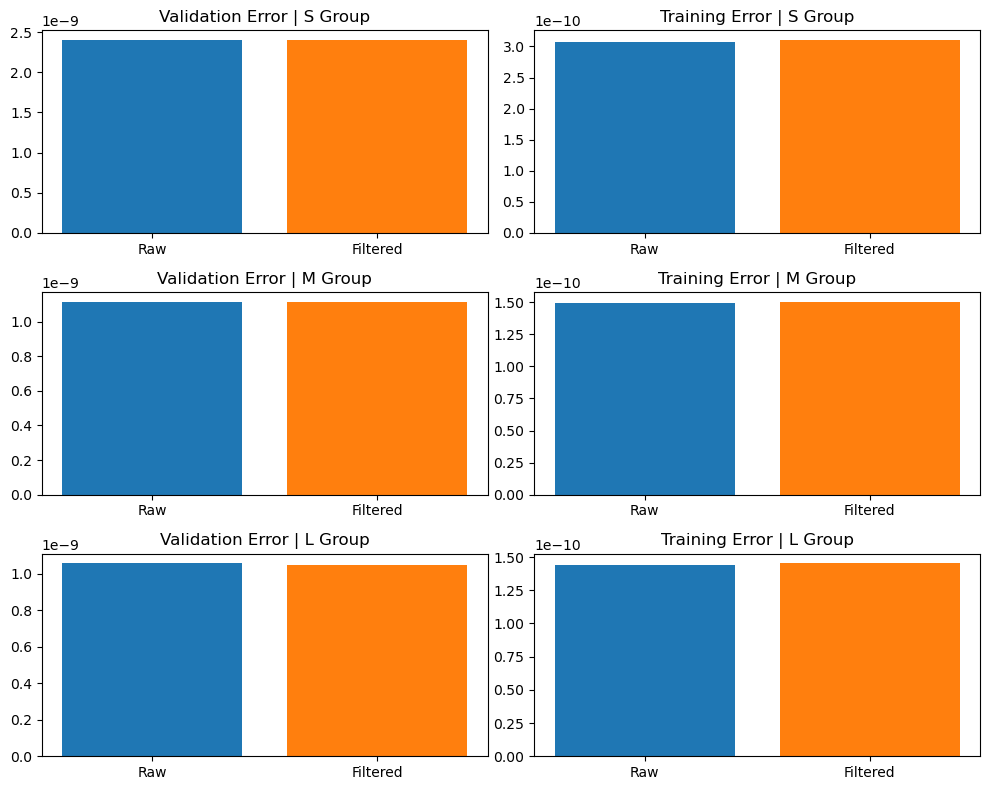

In [703]:
results = {}
models = {}
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
for i, group in enumerate(feature_groups.keys()):
    train, train_filtered, validation = get_splits(group, filtering_features, std_threshold=5)
    
    print("___________________________")
    print(f"Group: {group}")
    val_error, train_error, filtered_val_error, filtered_train_error, rf, rf_filtered = compare(train, train_filtered, validation)
    results[group] = val_error, train_error, filtered_val_error, filtered_train_error
    
    axes[i, 0].bar('Raw', val_error)
    axes[i, 0].bar('Filtered', filtered_val_error)
    axes[i, 0].set_title(f'Validation Error | {group} Group')
    
    axes[i, 1].bar('Raw', train_error)
    axes[i, 1].bar('Filtered', filtered_train_error)
    axes[i, 1].set_title(f'Training Error | {group} Group')

  
plt.tight_layout()
plt.show()

In [704]:
deviations = np.linspace(1, 6, 10)
trainin = {}
train_f = {}
validatio = {}
validatio_f = {}
for i, group in enumerate(feature_groups.keys()):
    break
    trainin[group] = []
    train_f[group] = []
    validatio[group] = []
    validatio_f[group] = []
    for std in deviations:
        train, train_filtered, validation = get_splits(group, std_threshold=std)
        val_error, train_error, filtered_val_error, filtered_train_error, rf, rf_filtered = compare(train, train_filtered, validation, verbose=False)
        trainin[group].append(train_error)
        train_f[group].append(filtered_train_error)
        validatio[group].append(val_error)
        validatio_f[group].append(filtered_val_error)
    

In [705]:
train1 = trainin['S']
training_f1 = train_f['S']
validation1 = validatio['S']
validation_f1 = validatio_f['S']
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(15, 8))

axes1.plot(deviations, train1, label='Raw')
axes1.plot(deviations, training_f1, label='Filtered')
axes1.set_title('Training Error VS. STD Threshold')
axes1.legend()

axes2.plot(deviations, validation1, label='Raw')
axes2.plot(deviations, validation_f1, label='Filtered')
axes2.set_title('Validation Error VS. STD Threshold')
axes2.legend()
plt.tight_layout()
plt.show()

KeyError: 'S'

In [ ]:
train1 = trainin['M']
training_f1 = train_f['M']
validation1 = validatio['M']
validation_f1 = validatio_f['M']
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(15, 8))

axes1.plot(deviations, train1, label='Raw')
axes1.plot(deviations, training_f1, label='Filtered')
axes1.set_title('Training Error VS. STD Threshold')
axes1.legend()

axes2.plot(deviations, validation1, label='Raw')
axes2.plot(deviations, validation_f1, label='Filtered')
axes2.set_title('Validation Error VS. STD Threshold')
axes2.legend()
plt.tight_layout()
plt.show()

In [ ]:
train1 = trainin['L']
training_f1 = train_f['L']
validation1 = validatio['L']
validation_f1 = validatio_f['L']
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(15, 8))

axes1.plot(deviations, train1, label='Raw')
axes1.plot(deviations, training_f1, label='Filtered')
axes1.set_title('Training Error VS. STD Threshold')
axes1.legend()

axes2.plot(deviations, validation1, label='Raw')
axes2.plot(deviations, validation_f1, label='Filtered')
axes2.set_title('Validation Error VS. STD Threshold')
axes2.legend()
plt.tight_layout()
plt.show()

## Which Features to Filter over

In [729]:
filtering_features = ['k18_fw_mean', 'g28_fw_mean', 'inj_i_mean', 'ext_i_mean', 'mid_i_mean', 'extraction_v_mean', 'puller_v_mean']
results = {}
for feature in filtering_features:
    # newz = copy.deepcopy(filtering_features)
    # newz.remove(feature)
    newz=[feature]
    train, train_filtered, validation = get_splits(group, newz, std_threshold=2)
    val_error, train_error, filtered_val_error, filtered_train_error, rf, rf_filtered = compare(train, train_filtered, validation, verbose=False)
    results[feature] = filtered_val_error
    results['Raw'] = val_error

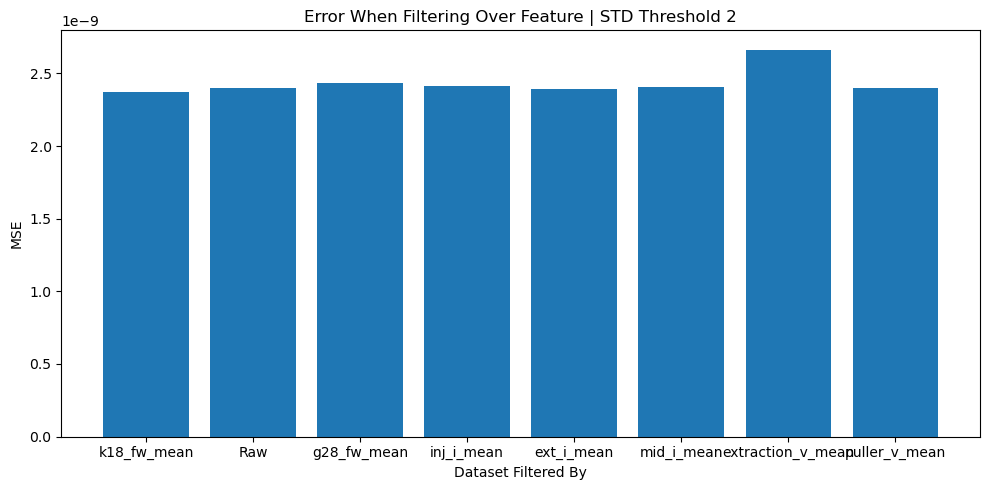

In [730]:
keys = list(results.keys())   # x labels (categories)
values = list(results.values())   # y values (heights of bars)

# Creating the bar plot
plt.figure(figsize=(10, 5))  # optional, to specify the size of the figure
plt.bar(keys, values)  # create bars with skyblue color

# Adding title and labels
plt.title(f'Error When Filtering Over Feature | STD Threshold {2}')
plt.xlabel('Dataset Filtered By')
plt.ylabel('MSE')

# Display the plot
plt.tight_layout()
plt.show()